In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
fedesoriano_heart_failure_prediction_path = kagglehub.dataset_download('fedesoriano/heart-failure-prediction')
fedesoriano_spanish_wine_quality_dataset_introduction_path = kagglehub.notebook_output_download('fedesoriano/spanish-wine-quality-dataset-introduction')

print('Data source import complete.')


Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Extracting files...
Data source import complete.


**STUDENTS**

**Jana Alyan Alzhrani**   446003431

**Jana musaed Almuqati**  446001852

**Sara saeed Alghamdi**   446004937

**Retaj Khaled Alashqar**  446008786

**Dataset Overview:** The dataset consists of 918 observations (rows) and 12 features (columns). It combines multiple cardiovascular datasets to help predict the likelihood of heart disease.

**Age:** Age of the patient [years] (Numerical)

**Sex:** Sex of the patient [M: Male, F: Female] (Categorical)  

**ChestPainType:** Chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic] (Categorical)  

**RestingBP:** Resting blood pressure [mm Hg] (Numerical)  

**Cholesterol:** Serum cholesterol [mm/dl] (Numerical)

**FastingBS:** Fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise] (Categorical/Binary)

**RestingECG:** Resting electrocardiogram results [Normal, ST: having ST-T wave abnormality, LVH: showing probable or definite left ventricular hypertrophy] (Categorical)

**MaxHR:** Maximum heart rate achieved [Numeric value between 60 and 202] (Numerical)

**ExerciseAngina:** Exercise-induced angina [Y: Yes, N: No] (Categorical/Binary)

**Oldpeak:** ST depression induced by exercise relative to rest (Numerical)

**ST_Slope:** The slope of the peak exercise ST segment [Up, Flat, Down] (Categorical)

**Target Variable:** HeartDisease[1: Heart Disease, 0: Normal]

**Machine Learning Task:** This is a Binary Classification problem, as the goal is to predict one of two distinct categories (whether a patient has heart disease or not) based on clinical attributes.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
df = pd.read_csv(os.path.join(fedesoriano_heart_failure_prediction_path, 'heart.csv'))

In [5]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
df.shape

(918, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


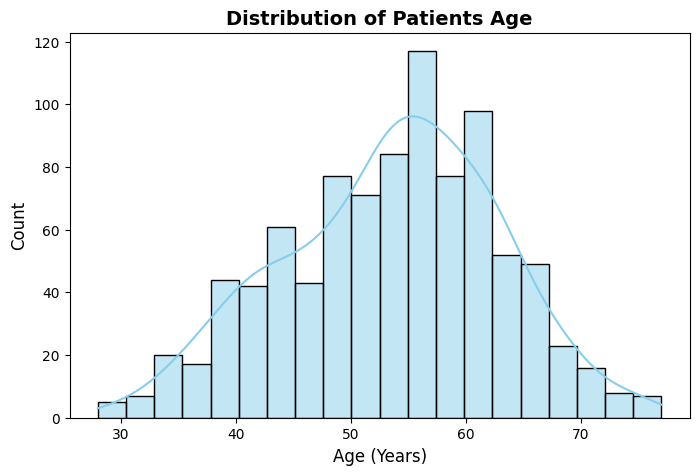

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Age', bins=20, kde=True, color='skyblue')

plt.title('Distribution of Patients Age', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.show()

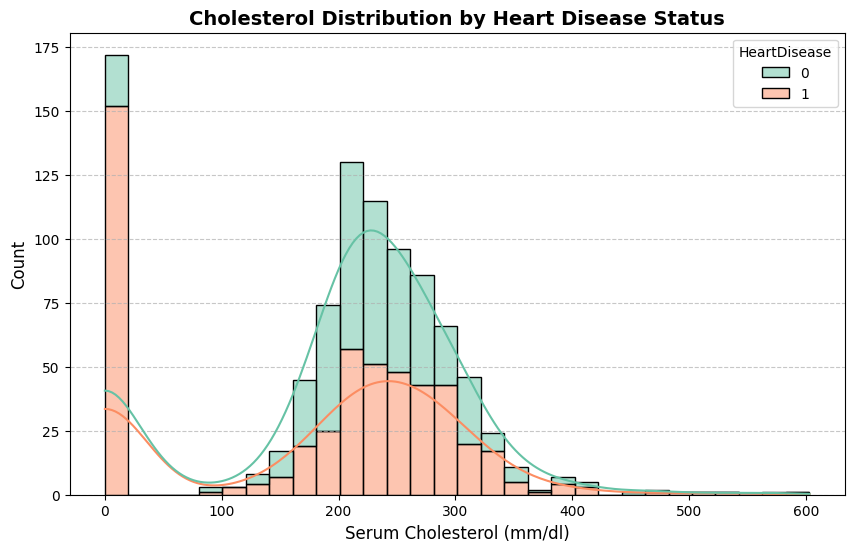

In [10]:
plt.figure(figsize=(10, 6))


sns.histplot(data=df, x='Cholesterol', hue='HeartDisease', bins=30, kde=True, palette='Set2', multiple='stack')


plt.title('Cholesterol Distribution by Heart Disease Status', fontsize=14, fontweight='bold')
plt.xlabel('Serum Cholesterol (mm/dl)', fontsize=12)
plt.ylabel('Count', fontsize=12)


plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

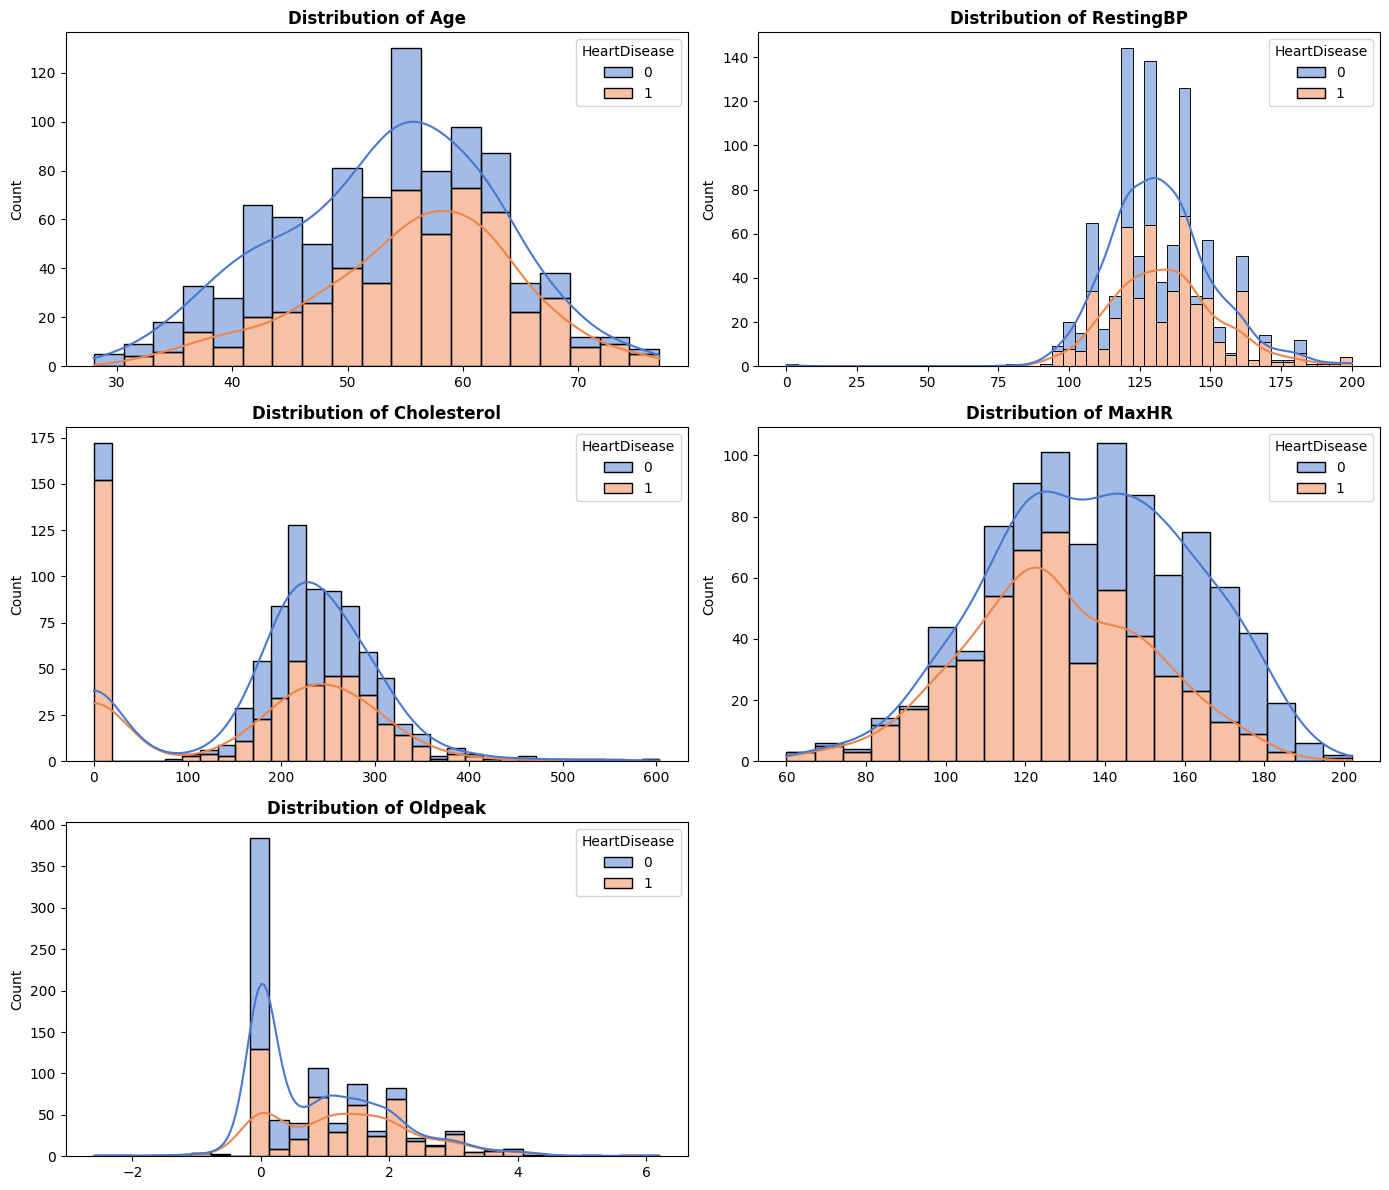

In [11]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.histplot(data=df, x=col, hue='HeartDisease', kde=True, ax=axes[i], palette='muted', multiple='stack')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

---
## Data Preparation


### Check for Missing Values and Zero Values

In [12]:
# Check for null values
print("Null values per column:")
print(df.isnull().sum())
print()

# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")
print()

# In this dataset, 0 in Cholesterol and RestingBP means missing data
print(f"Zero values in Cholesterol: {(df['Cholesterol'] == 0).sum()}")
print(f"Zero values in RestingBP:   {(df['RestingBP'] == 0).sum()}")

Null values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate rows: 0

Zero values in Cholesterol: 172
Zero values in RestingBP:   1


###### نفحص الأصفار في Cholesterol و RestingBP فقط لأن الصفر مستحيل طبياً فيهما
###### (كوليسترول = صفر أو ضغط دم = صفر يعني وفاة الشخص)
###### بمعنى أي قيمة صفر في هذين العمودين تمثل بيانات ناقصة وليست قيمة حقيقية

### Replace Zero Values with Median

In [13]:
# Replace zeros in Cholesterol with median
df['Cholesterol'] = df['Cholesterol'].replace(
    0,
    df[df['Cholesterol'] != 0]['Cholesterol'].median()
)

# Replace zeros in RestingBP with median
df['RestingBP'] = df['RestingBP'].replace(
    0,
    df[df['RestingBP'] != 0]['RestingBP'].median()
)


print(f"Dataset shape after cleaning: {df.shape}")
print()
print("Zero values after treatment:")
print(f"  Cholesterol: {(df['Cholesterol'] == 0).sum()}")
print(f"  RestingBP:   {(df['RestingBP'] == 0).sum()}")

Dataset shape after cleaning: (918, 12)

Zero values after treatment:
  Cholesterol: 0
  RestingBP:   0


###### نستبدل الأصفار بالـ Median وليس الـ Mean
###### لأن الـ Mean يتأثر بالقيم الشاذة (مثل كوليسترول 600)
###### بينما الـ Median أكثر استقراراً ويعطي تمثيلاً أدق للقيم الطبيعية

### Encode Categorical Features (One-Hot Encoding)

ML models cannot work with text labels — we convert them to numbers using `pd.get_dummies()`.
###### نستخدم One-Hot Encoding لأن الأعمدة النصية فئوية بدون ترتيب (Nominal)

In [14]:
# Identify categorical columns before encoding
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
print("Categorical columns to encode:", categorical_cols)
print()

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


print(f"Columns before encoding: {df.shape[1]}")
print(f"Columns after encoding:  {df_encoded.shape[1]}")
print()
print("Columns after encoding:")
print(df_encoded.columns.tolist())


Categorical columns to encode: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Columns before encoding: 12
Columns after encoding:  16

Columns after encoding:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


###  Normalize Numerical Features (StandardScaler)

We use `StandardScaler` so all numerical columns have **mean = 0** and **std = 1**.
This prevents features with large ranges (like Age vs. Oldpeak) from dominating the model.

In [15]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("Numerical columns after normalization (mean ≈ 0, std ≈ 1):")
print(df_encoded[numerical_cols].describe().loc[['mean', 'std']].round(2))

Numerical columns after normalization (mean ≈ 0, std ≈ 1):
      Age  RestingBP  Cholesterol  MaxHR  Oldpeak
mean -0.0        0.0          0.0    0.0      0.0
std   1.0        1.0          1.0    1.0      1.0


###### طبقناه على 5 اعمدة من أصل 6 رقمية
###### FastingBS مستثنى لأنه ثنائي (0 أو 1) يمثل نعم/لا
###### تطبيعه يحوله لأرقام عشرية ويفقده معناه الأصلي

### Split Data into Train / Test Sets

In [16]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set:  {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")
print(f"Features:      {X_train.shape[1]} columns")
print()
print(f"Target distribution in training set:")
print(y_train.value_counts())

Training set:  734 samples
Test set:      184 samples
Features:      15 columns

Target distribution in training set:
HeartDisease
1    401
0    333
Name: count, dtype: int64


# Model 1: Logistic Regression


**In this section, we build and evaluate the first model using Logistic Regression. We use the preprocessed data (encoded + normalized + split) from Members 1 and 2, then measure performance using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.**

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Step 1: Train the Model


**We initialize Logistic Regression and fit it on X_train / y_train prepared by Member 2.**

In [18]:
# Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train on the training set
log_reg.fit(X_train, y_train)

# Predict on the test set
y_pred = log_reg.predict(X_test)

print("Model training complete.")
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features used    : {X_train.shape[1]}")

Model training complete.
Training samples : 734
Test samples     : 184
Features used    : 15


# Step 2: (Accuracy / Precision / Recall / F1-Score)

**We compute four key evaluation metrics to measure model performance.**




**What each metric means:**

**• Accuracy:** overall correct predictions out of all predictions

**• Precision:**  out of predicted positives, how many are actually positive

**• Recall:**  out of actual positives, how many did we correctly detect

**• F1-Score:** harmonic mean of Precision and Recall (balance between both)


In [19]:
# Calculate metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 42)
print("    Logistic Regression — Evaluation")
print("=" * 42)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 42)
print()
print(classification_report(
    y_test, y_pred,
    target_names=['No Disease (0)', 'Heart Disease (1)']
))

    Logistic Regression — Evaluation
  Accuracy  : 0.8587  (85.87%)
  Precision : 0.9091
  Recall    : 0.8411
  F1-Score  : 0.8738

                   precision    recall  f1-score   support

   No Disease (0)       0.80      0.88      0.84        77
Heart Disease (1)       0.91      0.84      0.87       107

         accuracy                           0.86       184
        macro avg       0.85      0.86      0.86       184
     weighted avg       0.86      0.86      0.86       184



# Step 3: Confusion Matrix


**The confusion matrix shows where the model succeeds and where it makes mistakes broken down by True Positives, True Negatives, False Positives, and False Negatives.**

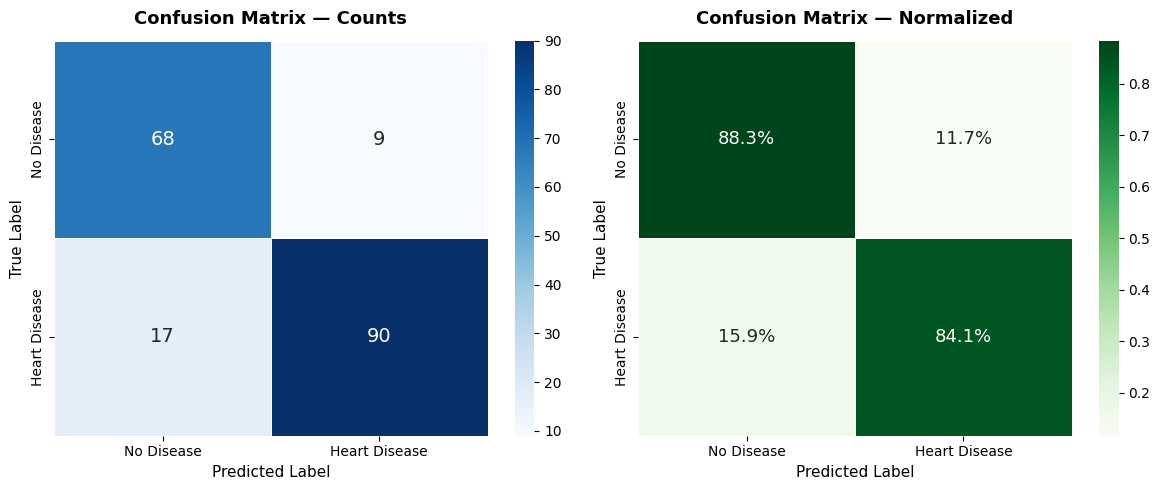

In [20]:
import numpy as np
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Raw counts ---
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Disease', 'Heart Disease'],
    yticklabels=['No Disease', 'Heart Disease'],
    linewidths=0.5, annot_kws={'size': 14},
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Counts', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# --- Right: Normalized (percentages) ---
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm,
    annot=True, fmt='.1%', cmap='Greens',
    xticklabels=['No Disease', 'Heart Disease'],
    yticklabels=['No Disease', 'Heart Disease'],
    linewidths=0.5, annot_kws={'size': 13},
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix — Normalized', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()

# Step 4: Model Interpretation

**We explain what the numbers mean clinically and which metrics matter most for heart disease prediction.**

In [21]:
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Breakdown:")
print(f"  True Positives  (TP) = {tp}  → correctly identified as Heart Disease")
print(f"  True Negatives  (TN) = {tn}  → correctly identified as No Disease")
print(f"  False Positives (FP) = {fp}  → predicted Disease, actually Healthy")
print(f"  False Negatives (FN) = {fn}  → missed actual Disease cases (critical!)")

print()
print("Interpretation:")
print(f"  - The model achieved {accuracy*100:.1f}% accuracy on unseen test data.")
print(f"  - Recall = {recall:.2f}: the model correctly detected {recall*100:.1f}% of actual")
print(f"    heart disease patients. In medical diagnosis, high Recall is")
print(f"    critical to minimize missed cases (False Negatives).")
print(f"  - Precision = {precision:.2f}: when the model predicts Heart Disease,")
print(f"    it is correct {precision*100:.1f}% of the time.")
print(f"  - F1-Score = {f1:.2f}: reflects a balanced performance between")
print(f"    Precision and Recall.")
print()

Confusion Matrix Breakdown:
  True Positives  (TP) = 90  → correctly identified as Heart Disease
  True Negatives  (TN) = 68  → correctly identified as No Disease
  False Positives (FP) = 9  → predicted Disease, actually Healthy
  False Negatives (FN) = 17  → missed actual Disease cases (critical!)

Interpretation:
  - The model achieved 85.9% accuracy on unseen test data.
  - Recall = 0.84: the model correctly detected 84.1% of actual
    heart disease patients. In medical diagnosis, high Recall is
    critical to minimize missed cases (False Negatives).
  - Precision = 0.91: when the model predicts Heart Disease,
    it is correct 90.9% of the time.
  - F1-Score = 0.87: reflects a balanced performance between
    Precision and Recall.



### DECISION TREE and  RANDOM FOREST and Compareing them



In [22]:

# TASK 3: DECISION TREE VS. RANDOM FOREST COMPARISON


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Train & Evaluate Decision Tree ---
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_probs = dt_model.predict_proba(X_test)[:, 1]

# --- 2. Train & Evaluate Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# --- 3. Compute Metrics ---
def calculate_all_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1_s = f1_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    return acc, prec, rec, f1_s, spec

dt_metrics = calculate_all_metrics(y_test, y_pred_dt)
rf_metrics = calculate_all_metrics(y_test, y_pred_rf)

# Print comparison results in the format your mates used
print("=" * 50)
print(f"{'Metric':<20} | {'Decision Tree':<13} | {'Random Forest':<13}")
print("-" * 50)
print(f"{'Accuracy':<20} | {dt_metrics[0]:.4f} ({dt_metrics[0]*100:.1f}%) | {rf_metrics[0]:.4f} ({rf_metrics[0]*100:.1f}%)")
print(f"{'Precision':<20} | {dt_metrics[1]:.4f}        | {rf_metrics[1]:.4f}")
print(f"{'Sensitivity (Recall)':<20} | {dt_metrics[2]:.4f}        | {rf_metrics[2]:.4f}")
print(f"{'Specificity':<20} | {dt_metrics[4]:.4f}        | {rf_metrics[4]:.4f}")
print(f"{'F1-Score':<20} | {dt_metrics[3]:.4f}        | {rf_metrics[3]:.4f}")
print("=" * 50)

Metric               | Decision Tree | Random Forest
--------------------------------------------------
Accuracy             | 0.8207 (82.1%) | 0.8478 (84.8%)
Precision            | 0.8854        | 0.8835
Sensitivity (Recall) | 0.7944        | 0.8505
Specificity          | 0.8571        | 0.8442
F1-Score             | 0.8374        | 0.8667


### Plot ROC Curves

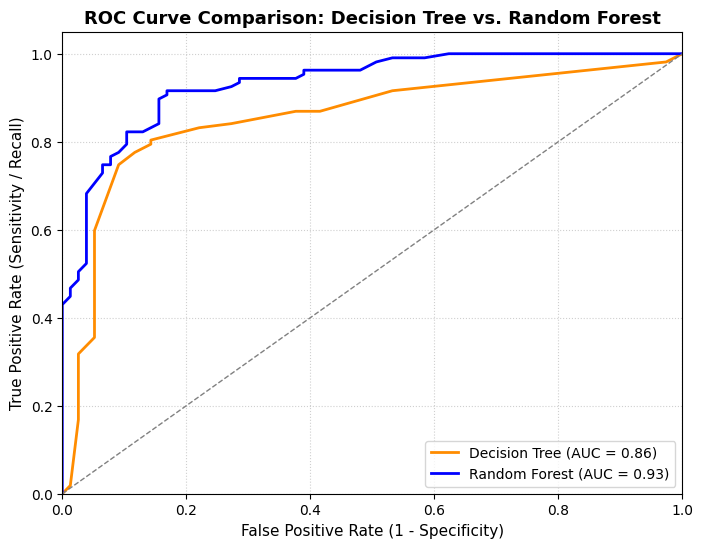

In [23]:
# --- 4. Plot ROC Curves ---
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curve Comparison: Decision Tree vs. Random Forest', fontsize=13, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# <span style="color: #1b4d3e;"> Final Model Comparison & Interpretation</span>

### 1. Analysis of the Results
Based on the metrics generated from our test data, we can draw a direct comparison between the two tree-based models:
* **Accuracy:** The **Random Forest Classifier** achieved an accuracy of **84.8%**, outperforming the single Decision Tree (**82.1%**) by roughly 2.7%.
* **Sensitivity (Recall):** This is the most critical metric for our clinical objective (detecting actual heart disease patients). The Random Forest successfully identified **85.1%** of patients with heart disease, whereas the single Decision Tree missed more cases, flagging only **79.4%**.
* **F1-Score:** Reflecting the overall balance between Precision and Recall, the Random Forest score of **0.8667** proves it is the more reliable and robust model overall.

### 2. Machine Learning Justification
* **Why the Random Forest Won:** A single Decision Tree creates a rigid set of rules based on the training data, which often leads to high variance and overfitting (memorizing the training data). Random Forest overcomes this by constructing an ensemble of 100 different trees using random subsets of data and features. By averaging their individual predictions, it cancels out structural noise, prevents overfitting, and performs significantly better on unseen patient data.

### 3. Healthcare & Project Conclusion
In medical screening systems, a **False Negative** (falsely telling a sick patient they are healthy) is a dangerous risk. Because the Random Forest model maximizes **Sensitivity** without causing a massive drop in **Specificity**, it stands out as the optimal choice.

**Group Recommendation:** For the final deployment of our Heart Failure Prediction project, we recommend utilizing the **Random Forest** configuration as an automated clinical assistant to safely flag high-risk cardiovascular patients.

---

# <span style="color: #1b4d3e;"> المقارنة النهائية بين النماذج وتفسير النتائج</span>

### 1. تحليل النتائج
بناءً على المقاييس المستخرجة من بيانات الاختبار، يمكننا إجراء مقارنة مباشرة بين النموذجَين القائمين على الأشجار:
* **الدقة (Accuracy):** حقق نموذج **الغابة العشوائية (Random Forest)** دقة تصل إلى **84.8%**، متفوقاً على **شجرة القرار (Decision Tree)** المفردة والتي حققت دقة قدرها **82.1%** (بفارق 2.7%).
* **الحساسية (Sensitivity / Recall):** يعد هذا المقياس هو الأكثر أهمية لأهدافنا الطبية (اكتشاف مرضى القلب الفعليين). نجح نموذج الغابة العشوائية في تحديد **85.1%** من المصابين، بينما أغفلت شجرة القرار حالات أكثر واكتشفت **79.4%** فقط.
* **مقياس F1-Score:** يعكس هذا المقياس التوازن العام بين الدقة والاستدعاء، وحصول الغابة العشوائية على **0.8667** يثبت أنه النموذج الأكثر استقراراً واعتمادية.

### 2. المبرر العلمي لتعلم الآلة (Machine Learning)
* **سبب تفوق الغابة العشوائية:** تميل شجرة القرار المفردة إلى حفظ بيانات التدريب وتشكيل قواعد صارمة، مما يؤدي إلى مشكلة "التكيف الزائد" (Overfitting) وضعف الأداء مع البيانات الجديدة. وتتغلب "الغابة العشوائية" على ذلك بإنشاء مجموعة مكونة من 100 شجرة مختلفة تعمل معاً بشكل عشوائي. ومن خلال دمج وحساب متوسط توقعاتها، يتم إلغاء الأخطاء الفردية للأشجار، ومنع التكيف الزائد، وتقديم أداء أفضل بكثير مع بيانات المرضى الجدد.

### 3. الاستنتاج الطبي والتوصية النهائية
في أنظمة الفحص الطبي، تمثل **السالبة الخاطئة (False Negative)** — وهي إخبار المريض المصاب بالخطأ أنه سليم — خطراً كبيراً على حياته. ولأن نموذج الغابة العشوائية يرفع نسبة **الحساسية (Sensitivity)** لأعلى درجة دون الإخلال بالمقاييس الأخرى، فإنه يمثل الخيار الأمثل للمشروع.

**توصية المجموعة:** للمرحلة النهائية من مشروع التنبؤ بفشل القلب، نوصي باعتماد نموذج **الغابة العشوائية (Random Forest)** ليعمل كمساعد إكلينيكي رقمي لتحديد وتصنيف المرضى الأكثر عرضة للمخاطر بدقة وأمان.